In [1]:
import random
import numpy as np
import networkx as nx
from pathlib import Path
from generator import GraphGenerator

In [2]:
path_to_networks = Path('./networks')

## Complete Graph

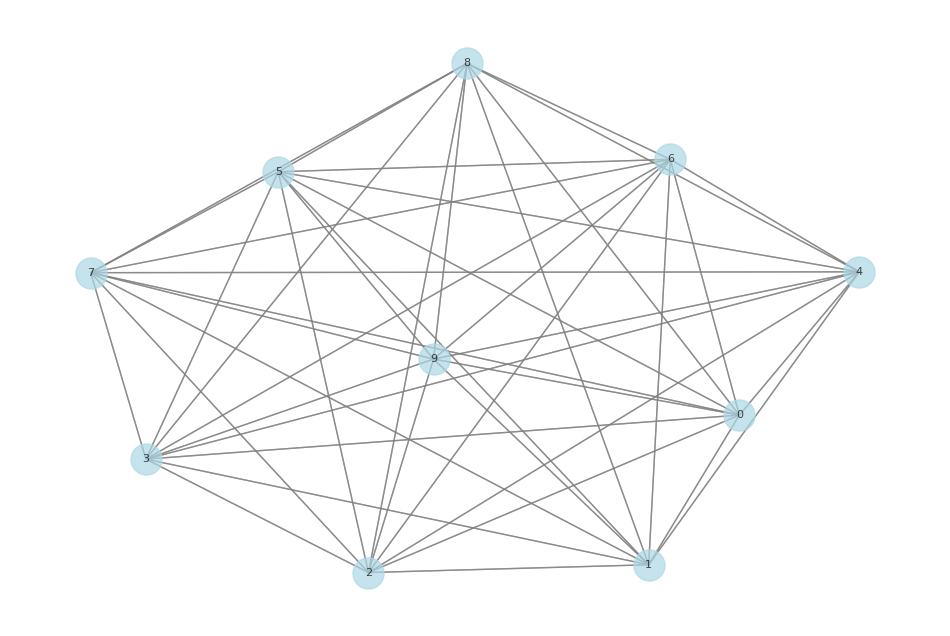

In [3]:
class CompleteGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes
        """
        self.graph = nx.complete_graph(n)


generator = CompleteGraph()
generator.generate_graph(10)
generator.visualise()

## Weighted Graph

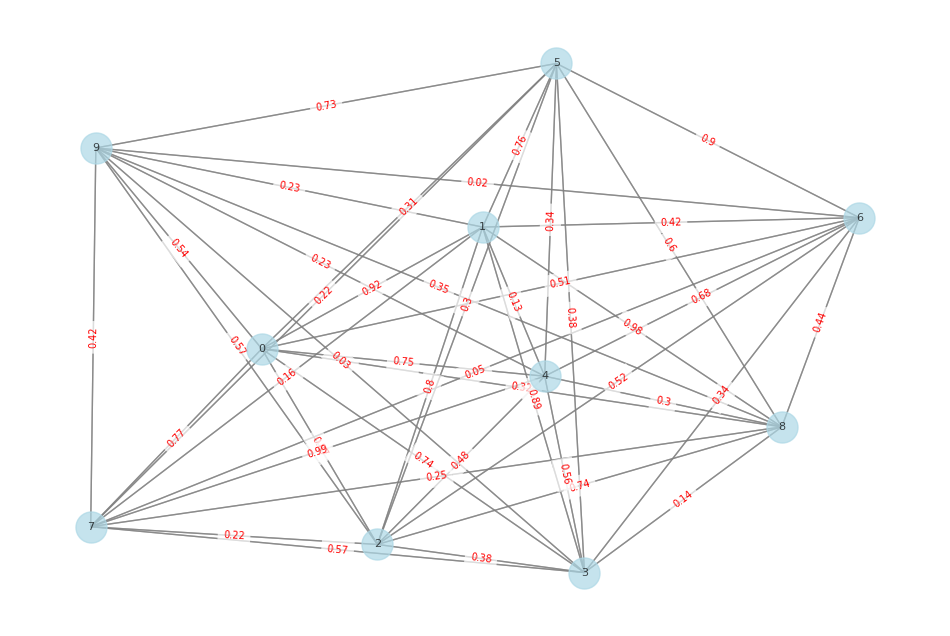

In [4]:
class WeightedGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes, with random weights
        """
        self.graph = nx.complete_graph(n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = WeightedGraph()
generator.generate_graph(10)
generator.visualise()

## Barabási-Albert Graph

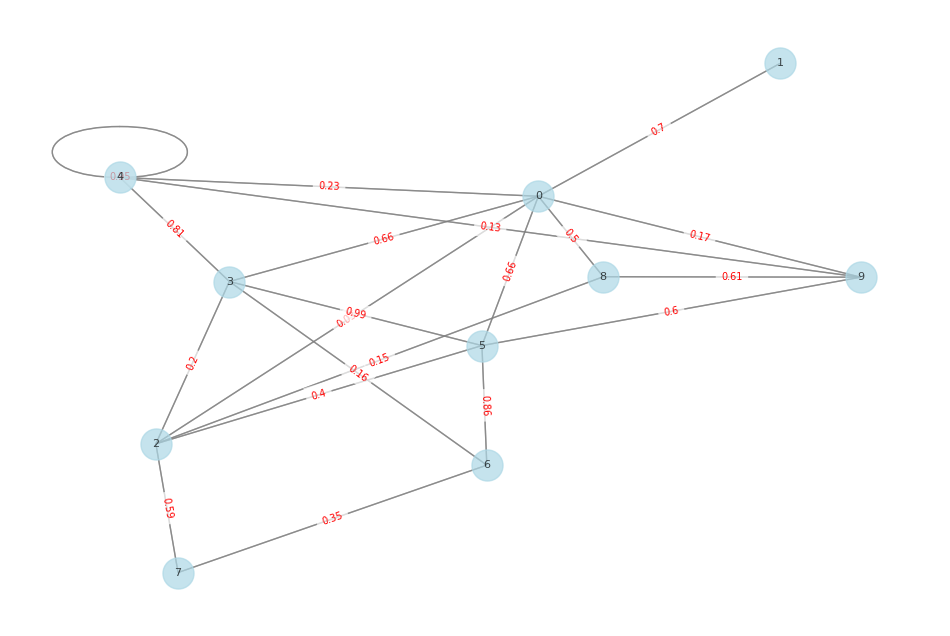

In [5]:
class BarbasiAlbertGraph(GraphGenerator):
    def generate_graph(self, n, m=2, community_prob=0.3):
        """
        Generates a realistic social network graph with:
        - Scale-free properties (Barabási-Albert model)
        - Community structure (random clustering)
        - Weighted edges (interaction strength)

        Args:
            n: Number of nodes.
            m: Number of edges each new node forms (preferential attachment).
            community_prob: Probability of within-community connections.
        """
        self.graph = nx.barabasi_albert_graph(n, m)

        for u, v in self.graph.edges():
            if random.random() < community_prob:
                for _ in range(2):
                    new_node = random.choice(list(self.graph.neighbors(u)))
                    if not self.graph.has_edge(new_node, v):
                        self.graph.add_edge(new_node, v)

        # Assign random weights to edges to mimic interaction frequency
        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = BarbasiAlbertGraph()
generator.generate_graph(10)
generator.visualise()

## Full r-ary Tree Graph

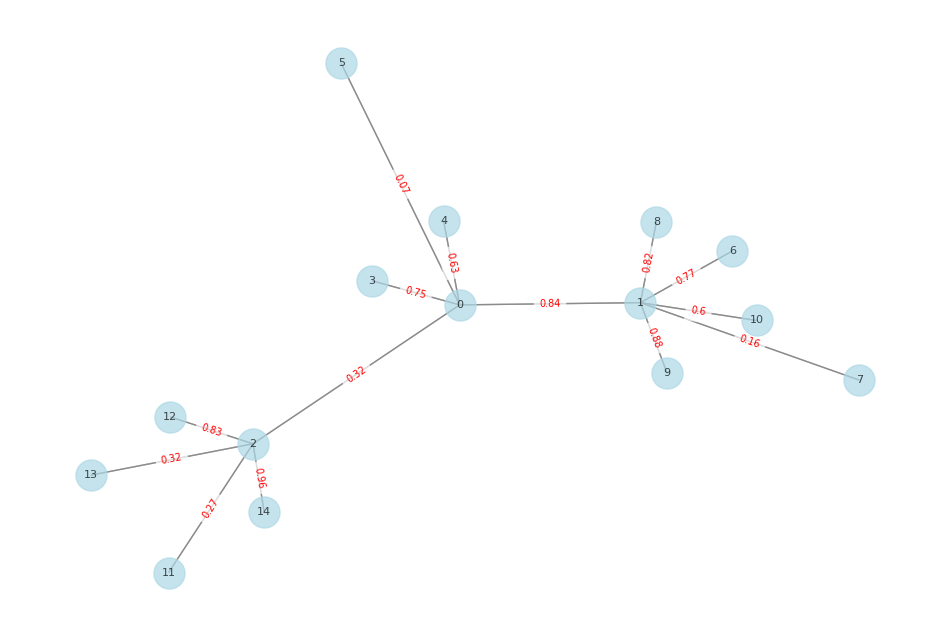

In [6]:
class FullRaryTree(GraphGenerator):
    def generate_graph(self, r, n):
        """
        Generates a full r-ary tree of n nodes with r branching factor, with random weights
        """
        self.graph = nx.full_rary_tree(r, n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = FullRaryTree()
generator.generate_graph(5, 15)
generator.visualise()

## Erdos Renyi Graph

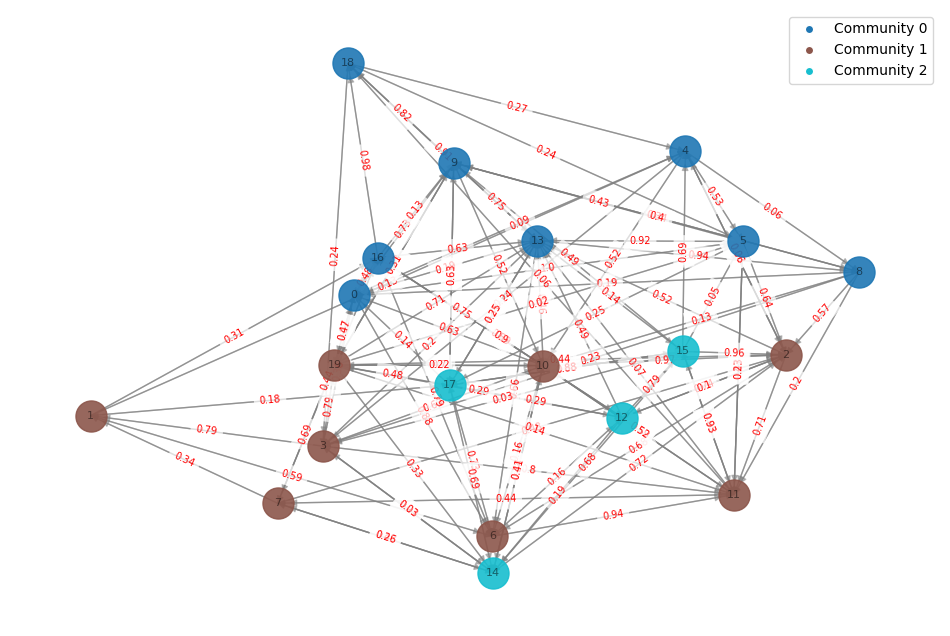

In [7]:
class ErdosRenyiGraph(GraphGenerator):
    def generate_graph(self, n, p, max_communities=5):
        """
        Generates a random graph, also known as an Erdős-Rényi graph or a binomial graph, with random weights
        """
        self.graph = nx.erdos_renyi_graph(
            n,
            p,
            directed=True,
            seed=np.random.default_rng(),
        )

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = ErdosRenyiGraph()
generator.generate_graph(20, 0.3)
generator.visualise()